# ECGR 4106 Homework 1 — CIFAR-10 CNN Comparison

**Student:** Andrew Dominguez Luna  
**Course:** ECGR 4106 Deep Learning  
**Homework:** Homework 1    

GitHub repository:

`https://github.com/adomin10-prog/ECGR4106-HW--CIFAR10-CNNs`


## 1. Set Google Colab to GPU

Before running:

1. Click `Runtime`
2. Click `Change runtime type`
3. Set `Hardware accelerator` to `T4 GPU`
4. Click `Save`

Running the full homework experiment on CPU is not recommended. CPU takes too long.

## 2. Clone the GitHub repository

This cell downloads the repository into Colab.

In [ ]:
import os
import shutil
from pathlib import Path

REPO_URL = "https://github.com/adomin10-prog/ECGR4106-HW--CIFAR10-CNNs.git"
REPO_DIR = Path("/content/ECGR4106-HW--CIFAR10-CNNs")

if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

!git clone {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
print("Current folder:", Path.cwd())

Cloning into '/content/ECGR4106-HW--CIFAR10-CNNs'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 80 (delta 24), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 40.94 KiB | 5.12 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/ECGR4106-HW--CIFAR10-CNNs
Current folder: /content/ECGR4106-HW--CIFAR10-CNNs


## 3. Install requirements

This installs the packages listed in the repo's `requirements.txt`.

In [ ]:
%pip install -q -r requirements.txt

## 4. Confirm GPU and PyTorch setup

In [ ]:
import sys
import platform
import torch

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled. Go to Runtime -> Change runtime type -> T4 GPU.")

Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA available: True
Selected device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


### 5. Import the code from the GitHub repository

This cell imports the existing model, data, metric, plotting, and seed functions from the repo.


In [ ]:
import csv
import json
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import display, Image

# These imports come directly from the GitHub repository files.
from models.alexnet_cifar import AlexNetCIFAR
from models.vgg_cifar import VGGCIFAR
from models.resnet_cifar import ResNet11CIFAR, ResNet18CIFAR

from utils.data import get_cifar10_loaders, CIFAR10_CLASSES
from utils.metrics import evaluate, count_trainable_parameters
from utils.plotting import plot_curves, plot_confusion_matrix
from utils.seed import set_seed

# These functions are also already defined in train.py.
from train import build_model, train_one_epoch

print("Repository code imported successfully.")

Repository code imported successfully.


## 7. Experiment settings

For final submission, leave:

```python
RUN_FULL_HOMEWORK = True
```

In [ ]:
RUN_FULL_HOMEWORK = True

SEED = 42
BATCH_SIZE = 128
NUM_WORKERS = 2

DATA_DIR = "./data"
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)

print("RUN_FULL_HOMEWORK:", RUN_FULL_HOMEWORK)
print("Batch size:", BATCH_SIZE)
print("Results folder:", RESULTS_DIR.resolve())

RUN_FULL_HOMEWORK: True
Batch size: 128
Results folder: /content/ECGR4106-HW--CIFAR10-CNNs/results


## 8. Load CIFAR-10 using the repo's data function


In [ ]:
train_loader, val_loader, test_loader = get_cifar10_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    seed=SEED,
    num_workers=NUM_WORKERS
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

100%|██████████| 170M/170M [52:16<00:00, 54.4kB/s]


Training batches: 352
Validation batches: 40
Test batches: 79
Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])


## 9. Check model output shapes and parameter counts

The model classes come directly from the repo:

- `models/alexnet_cifar.py`
- `models/vgg_cifar.py`
- `models/resnet_cifar.py`

The `build_model()` function comes from `train.py`.

In [ ]:
model_names = ["alexnet", "vgg", "resnet11", "resnet18"]

for model_name in model_names:
    model = build_model(model_name, dropout=0.0)
    sample_output = model(torch.zeros(2, 3, 32, 32))
    params = count_trainable_parameters(model)

    print(
        f"{model_name:8s} | output shape: {tuple(sample_output.shape)} | "
        f"trainable parameters: {params:,}"
    )

alexnet  | output shape: (2, 10) | trainable parameters: 3,192,458
vgg      | output shape: (2, 10) | trainable parameters: 3,586,698
resnet11 | output shape: (2, 10) | trainable parameters: 4,903,242
resnet18 | output shape: (2, 10) | trainable parameters: 11,173,962


## 10. Experiment list

These are the full homework model/dropout configurations.

- AlexNet and VGG run for 30 epochs.
- ResNet-11 and ResNet-18 run for 50 epochs.
- Each model is tested with dropout values of `0.0`, `0.3`, and `0.5`.

In [ ]:
FULL_EXPERIMENTS = [
    # model, dropout, epochs, learning rate
    ("alexnet", 0.0, 30, 0.01),
    ("alexnet", 0.3, 30, 0.01),
    ("alexnet", 0.5, 30, 0.01),

    ("vgg", 0.0, 30, 0.01),
    ("vgg", 0.3, 30, 0.01),
    ("vgg", 0.5, 30, 0.01),

    ("resnet11", 0.0, 50, 0.1),
    ("resnet11", 0.3, 50, 0.1),
    ("resnet11", 0.5, 50, 0.1),

    ("resnet18", 0.0, 50, 0.1),
    ("resnet18", 0.3, 50, 0.1),
    ("resnet18", 0.5, 50, 0.1),
]

QUICK_TEST_EXPERIMENTS = [
    ("alexnet", 0.0, 1, 0.01),
    ("vgg", 0.0, 1, 0.01),
    ("resnet11", 0.0, 1, 0.1),
    ("resnet18", 0.0, 1, 0.1),
]

experiments = FULL_EXPERIMENTS if RUN_FULL_HOMEWORK else QUICK_TEST_EXPERIMENTS

experiment_df = pd.DataFrame(
    experiments,
    columns=["model", "dropout", "epochs", "learning_rate"]
)

display(experiment_df)

,model,dropout,epochs,learning_rate
0,alexnet,0.0,30,0.01
1,alexnet,0.3,30,0.01
2,alexnet,0.5,30,0.01
3,vgg,0.0,30,0.01
4,vgg,0.3,30,0.01
5,vgg,0.5,30,0.01
6,resnet11,0.0,50,0.10
7,resnet11,0.3,50,0.10
8,resnet11,0.5,50,0.10
9,resnet18,0.0,50,0.10


## 11. Notebook experiment runner using repo functions

This cell is the notebook version of the training process.

It uses the existing repo functions:

- `build_model()` from `train.py`
- `train_one_epoch()` from `train.py`
- `evaluate()` from `utils/metrics.py`
- `plot_curves()` from `utils/plotting.py`
- `plot_confusion_matrix()` from `utils/plotting.py`
- `count_trainable_parameters()` from `utils/metrics.py`



In [ ]:
def run_experiment_from_repo_code(
    model_name: str,
    dropout: float,
    epochs: int,
    learning_rate: float,
    skip_if_finished: bool = True,
):
    dropout_tag = str(dropout).replace(".", "")
    run_name = f"{model_name}_dropout{dropout_tag}"
    output_dir = RESULTS_DIR / run_name
    output_dir.mkdir(parents=True, exist_ok=True)

    config_path = output_dir / "config.json"
    log_path = output_dir / "training_log.csv"
    best_model_path = output_dir / "best_model.pt"
    final_results_path = output_dir / "final_results.json"

    if skip_if_finished and config_path.exists() and log_path.exists() and final_results_path.exists():
        print(f"Skipping completed run: {run_name}")
        log_df = pd.read_csv(log_path)
        with open(final_results_path, "r") as f:
            final_results = json.load(f)

        return {
            "run": run_name,
            "model": model_name,
            "dropout": dropout,
            "epochs": epochs,
            "parameters": final_results["parameters"],
            "best_validation_accuracy": final_results["best_validation_accuracy"],
            "test_accuracy": final_results["test_accuracy"],
            "test_loss": final_results["test_loss"],
            "avg_epoch_time_sec": log_df["epoch_time_sec"].mean(),
            "device": str(device),
        }

    set_seed(SEED)

    model = build_model(model_name, dropout).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=0.9,
        weight_decay=5e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    param_count = count_trainable_parameters(model)

    config = {
        "model": model_name,
        "dropout": dropout,
        "epochs": epochs,
        "batch_size": BATCH_SIZE,
        "learning_rate": learning_rate,
        "momentum": 0.9,
        "weight_decay": 5e-4,
        "scheduler": "CosineAnnealingLR",
        "seed": SEED,
        "train_size": 45000,
        "validation_size": 5000,
        "test_size": 10000,
        "parameters": param_count,
        "device": str(device),
        "torch_version": torch.__version__,
        "python_version": platform.python_version(),
        "platform": platform.platform(),
    }

    if torch.cuda.is_available():
        config["gpu_name"] = torch.cuda.get_device_name(0)
        config["cuda_version"] = torch.version.cuda

    with open(config_path, "w") as f:
        json.dump(config, f, indent=4)

    with open(log_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "epoch",
            "train_loss",
            "train_accuracy",
            "val_loss",
            "val_accuracy",
            "epoch_time_sec",
            "learning_rate"
        ])

    best_val_acc = 0.0

    print("=" * 90)
    print(f"Run: {run_name}")
    print(f"Device: {device}")
    print(f"Trainable parameters: {param_count:,}")
    print("=" * 90)

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc, _ = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step()

        epoch_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]["lr"]

        with open(log_path, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch,
                train_loss,
                train_acc,
                val_loss,
                val_acc,
                epoch_time,
                current_lr
            ])

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"train loss {train_loss:.4f} | "
            f"train acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_acc:.4f} | "
            f"time {epoch_time:.1f}s"
        )

    model.load_state_dict(
        torch.load(best_model_path, map_location=device)
    )

    test_loss, test_acc, test_cm = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    final_results = {
        "best_validation_accuracy": best_val_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "parameters": param_count
    }

    with open(final_results_path, "w") as f:
        json.dump(final_results, f, indent=4)

    plot_curves(
        log_csv_path=str(log_path),
        output_dir=str(output_dir),
        title=run_name
    )

    plot_confusion_matrix(
        cm=test_cm,
        class_names=CIFAR10_CLASSES,
        output_path=str(output_dir / "confusion_matrix.png"),
        title=f"{run_name}: Test Confusion Matrix"
    )

    print(f"Final test accuracy for {run_name}: {test_acc:.4f}")
    print(f"Results saved to: {output_dir}")

    log_df = pd.read_csv(log_path)

    return {
        "run": run_name,
        "model": model_name,
        "dropout": dropout,
        "epochs": epochs,
        "parameters": param_count,
        "best_validation_accuracy": best_val_acc,
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "avg_epoch_time_sec": log_df["epoch_time_sec"].mean(),
        "device": str(device),
    }

## 12. Run all experiments

This can take a long time because it trains all required models.

In [ ]:
all_results = []

for model_name, dropout, epochs, learning_rate in experiments:
    result = run_experiment_from_repo_code(
        model_name=model_name,
        dropout=dropout,
        epochs=epochs,
        learning_rate=learning_rate,
        skip_if_finished=True
    )

    all_results.append(result)

summary_df = pd.DataFrame(all_results)
display(summary_df)

Run: alexnet_dropout00
Device: cuda
Trainable parameters: 3,192,458
Epoch 001/30 | train loss 2.0834 | train acc 0.2198 | val loss 1.7531 | val acc 0.3454 | time 3.0s
Epoch 002/30 | train loss 1.6180 | train acc 0.3989 | val loss 1.4097 | val acc 0.4840 | time 2.1s
Epoch 003/30 | train loss 1.3926 | train acc 0.4855 | val loss 1.2565 | val acc 0.5458 | time 2.0s
Epoch 004/30 | train loss 1.2320 | train acc 0.5511 | val loss 1.1117 | val acc 0.5906 | time 2.0s
Epoch 005/30 | train loss 1.0838 | train acc 0.6127 | val loss 0.9294 | val acc 0.6690 | time 2.0s
Epoch 006/30 | train loss 0.9557 | train acc 0.6607 | val loss 0.8685 | val acc 0.6944 | time 2.0s
Epoch 007/30 | train loss 0.8603 | train acc 0.6961 | val loss 0.7653 | val acc 0.7244 | time 2.0s
Epoch 008/30 | train loss 0.7899 | train acc 0.7210 | val loss 0.6751 | val acc 0.7560 | time 2.0s
Epoch 009/30 | train loss 0.7236 | train acc 0.7465 | val loss 0.7300 | val acc 0.7402 | time 2.0s
Epoch 010/30 | train loss 0.6847 | train 

,run,model,dropout,epochs,parameters,best_validation_accuracy,test_accuracy,test_loss,avg_epoch_time_sec,device
0,alexnet_dropout00,alexnet,0.0,30,3192458,0.8584,0.8517,0.447245,2.064835,cuda
1,alexnet_dropout03,alexnet,0.3,30,3192458,0.8554,0.8500,0.443515,2.050161,cuda
2,alexnet_dropout05,alexnet,0.5,30,3192458,0.8486,0.8473,0.452922,2.056139,cuda
3,vgg_dropout00,vgg,0.0,30,3586698,0.1028,0.1000,2.302670,2.038783,cuda
4,vgg_dropout03,vgg,0.3,30,3586698,0.1028,0.1000,2.302676,2.063646,cuda
5,vgg_dropout05,vgg,0.5,30,3586698,0.1028,0.1000,2.302674,2.047839,cuda
6,resnet11_dropout00,resnet11,0.0,50,4903242,0.9396,0.9280,0.247211,1.988500,cuda
7,resnet11_dropout03,resnet11,0.3,50,4903242,0.9354,0.9299,0.245837,1.994428,cuda
8,resnet11_dropout05,resnet11,0.5,50,4903242,0.9344,0.9298,0.233818,1.981786,cuda
9,resnet18_dropout00,resnet18,0.0,50,11173962,0.9440,0.9335,0.237261,3.312322,cuda


## 13. Final summary table and accuracy chart

,run,model,dropout,epochs,parameters,best_validation_accuracy,test_accuracy,test_loss,avg_epoch_time_sec,device
10,resnet18_dropout03,resnet18,0.3,50,11173962,0.9430,0.9394,0.226434,3.324515,cuda
11,resnet18_dropout05,resnet18,0.5,50,11173962,0.9430,0.9393,0.236496,3.322602,cuda
9,resnet18_dropout00,resnet18,0.0,50,11173962,0.9440,0.9335,0.237261,3.312322,cuda
7,resnet11_dropout03,resnet11,0.3,50,4903242,0.9354,0.9299,0.245837,1.994428,cuda
8,resnet11_dropout05,resnet11,0.5,50,4903242,0.9344,0.9298,0.233818,1.981786,cuda
6,resnet11_dropout00,resnet11,0.0,50,4903242,0.9396,0.9280,0.247211,1.988500,cuda
0,alexnet_dropout00,alexnet,0.0,30,3192458,0.8584,0.8517,0.447245,2.064835,cuda
1,alexnet_dropout03,alexnet,0.3,30,3192458,0.8554,0.8500,0.443515,2.050161,cuda
2,alexnet_dropout05,alexnet,0.5,30,3192458,0.8486,0.8473,0.452922,2.056139,cuda
3,vgg_dropout00,vgg,0.0,30,3586698,0.1028,0.1000,2.302670,2.038783,cuda


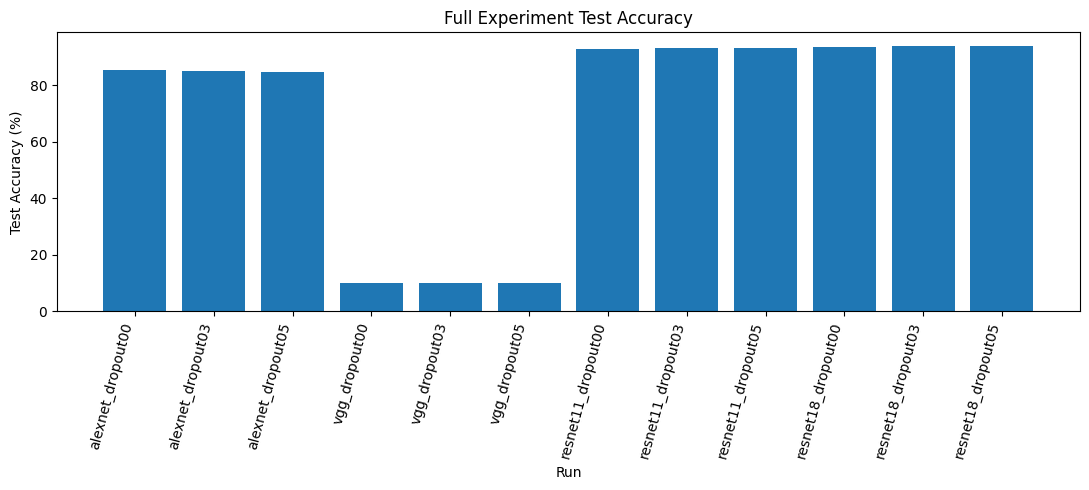

Saved summary table: results/full_experiment_summary.csv
Saved bar chart: results/full_experiment_accuracy_bar_chart.png


In [ ]:
summary_df = pd.DataFrame(all_results)

summary_path = RESULTS_DIR / "full_experiment_summary.csv"
summary_df.to_csv(summary_path, index=False)

display(summary_df.sort_values("test_accuracy", ascending=False))

plt.figure(figsize=(11, 5))
plt.bar(summary_df["run"], summary_df["test_accuracy"] * 100.0)
plt.xticks(rotation=75, ha="right")
plt.xlabel("Run")
plt.ylabel("Test Accuracy (%)")
plt.title("Full Experiment Test Accuracy")
plt.tight_layout()

chart_path = RESULTS_DIR / "full_experiment_accuracy_bar_chart.png"
plt.savefig(chart_path, dpi=200)
plt.show()

print("Saved summary table:", summary_path)
print("Saved bar chart:", chart_path)

## 14. Best model

In [ ]:
best_row = summary_df.loc[summary_df["test_accuracy"].idxmax()]

print("Best model based on test accuracy:")
display(best_row.to_frame(name="value"))

Best model based on test accuracy:


,value
run,resnet18_dropout03
model,resnet18
dropout,0.3
epochs,50
parameters,11173962
best_validation_accuracy,0.943
test_accuracy,0.9394
test_loss,0.226434
avg_epoch_time_sec,3.324515
device,cuda
